# Fig 3b — Classification performance vs model size

Scatter plot of mean AUPRC (default: **MIL** aggregation, 5-fold CV) against foundation-model parameter count.
Set `STRATEGY` to `'vote'` or `'avg'` in the config cell to switch aggregation.

Zero-parameter baselines (HVG, PCA [20], scVI) are shown as dashed horizontal reference lines.
Finetune / continue / Full variants and PCA [50]/[100] are excluded from the comparison.

Data source: `scFM_eval/results/classification.metrics.csv`  
Parameter counts were verified from local checkpoints where available (see `MODEL_PARAM_SIZES` below).

In [28]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO_ROOT = Path('../../').resolve()
METRICS_PATH = REPO_ROOT / 'results' / 'classification.metrics.csv'
PLOTS_DIR = Path('./plots')
METRICS_OUT_DIR = Path('./metrics')
PLOTS_DIR.mkdir(exist_ok=True)
METRICS_OUT_DIR.mkdir(exist_ok=True)

# Aggregation strategy: 'MIL' (default), 'vote', or 'avg'
STRATEGY = 'MIL'

In [29]:
# Parameter counts (absolute numbers).
# Verified from /home/haitham/mnt/MODELS/ checkpoints unless noted.
MODEL_PARAM_SIZES: dict[str, int] = {
    # Baselines — no pretrained transformer backbone
    'HVG': 0,
    'PCA [20]': 0,
    'PCA [50]': 0,
    'PCA [100]': 0,
    'scVI': 0,
    # Geneformer (pytorch_model.bin / model.safetensors)
    'GF-V1': 16_825_252,          # Geneformer-V1-10M/pytorch_model.bin (named "10M")
    'GF-V1 [finetune]': 16_825_252,
    'GF-V2': 104_387_072,         # Geneformer-V2-104M/model.safetensors
    'GF-V2 [cancer]': 104_387_072,
    'GF-V2 [finetune]': 104_387_072,
    'GF-V2-Deep': 316_355_328,    # Geneformer-V2-316M/model.safetensors
    # scGPT
    'scGPT': 51_326_464,          # scGPT_human/best_model.pt
    'scGPT [cancer]': 51_326_464, # scGPT_cancer/best_model.pt
    # Other foundation models
    'scFoundation': 100_000_000,  # published model size (100M)
    'CellPLM': 82_360_031,        # 20231027_85M.best.ckpt (marketed as 85M)
    'SCimiarity': 31_152_262,     # model_v1.1/encoder.ckpt
    'Nicheformer': 49_302_040,    # nicheformer.ckpt (Nature Methods: 49.3M)
    'scConcept': 30_000_000,      # Corpus-30M / corpus40M-model30M (HF card)
    'STATE': 600_000_000,         # arcinstitute/SE-600M (marketed size)
}

In [30]:
MODEL_PARAM_SOURCES: dict[str, str] = {
    'HVG': 'baseline (no pretrained backbone)',
    'PCA [20]': 'baseline (no pretrained backbone)',
    'PCA [50]': 'baseline (no pretrained backbone)',
    'PCA [100]': 'baseline (no pretrained backbone)',
    'scVI': 'baseline (no pretrained backbone)',
    'GF-V1': 'Geneformer-V1-10M/pytorch_model.bin (checkpoint count; marketed as 10M)',
    'GF-V1 [finetune]': 'same architecture as GF-V1',
    'GF-V2': 'Geneformer-V2-104M/model.safetensors',
    'GF-V2 [cancer]': 'Geneformer-V2-104M/model.safetensors',
    'GF-V2 [finetune]': 'same architecture as GF-V2',
    'GF-V2-Deep': 'Geneformer-V2-316M/model.safetensors',
    'scGPT': 'scGPT_human/best_model.pt',
    'scGPT [cancer]': 'scGPT_cancer/best_model.pt',
    'scFoundation': 'published model size (100M)',
    'CellPLM': '20231027_85M.best.ckpt (marketed as 85M)',
    'SCimiarity': 'model_v1.1/encoder.ckpt',
    'Nicheformer': 'nicheformer.ckpt (Nature Methods: 49.3M)',
    'scConcept': 'Corpus-30M / corpus40M-model30M (HF card)',
    'STATE': 'arcinstitute/SE-600M (marketed size)',
}

param_sizes_df = pd.DataFrame(
    {
        'model_display': list(MODEL_PARAM_SIZES.keys()),
        'params': list(MODEL_PARAM_SIZES.values()),
    }
)
param_sizes_df['params_M'] = param_sizes_df['params'].apply(lambda x: round(x / 1e6, 3) if x else 0)
param_sizes_df['params_M_label'] = param_sizes_df['params'].apply(
    lambda x: f'{int(round(x / 1e6))}M' if x else '0'
)
param_sizes_df['source'] = param_sizes_df['model_display'].map(MODEL_PARAM_SOURCES)
param_sizes_df = param_sizes_df.sort_values(['params', 'model_display']).reset_index(drop=True)

param_sizes_path = METRICS_OUT_DIR / 'model_param_sizes.csv'
param_sizes_df.to_csv(param_sizes_path, index=False)
param_sizes_df

,model_display,params,params_M,params_M_label,source
0,HVG,0,0.000,0,baseline (no pretrained backbone)
1,PCA [100],0,0.000,0,baseline (no pretrained backbone)
2,PCA [20],0,0.000,0,baseline (no pretrained backbone)
3,PCA [50],0,0.000,0,baseline (no pretrained backbone)
4,scVI,0,0.000,0,baseline (no pretrained backbone)
5,GF-V1,16825252,16.825,17M,Geneformer-V1-10M/pytorch_model.bin (checkpoin...
6,GF-V1 [finetune],16825252,16.825,17M,same architecture as GF-V1
7,scConcept,30000000,30.000,30M,Corpus-30M / corpus40M-model30M (HF card)
8,SCimiarity,31152262,31.152,31M,model_v1.1/encoder.ckpt
9,Nicheformer,49302040,49.302,49M,nicheformer.ckpt (Nature Methods: 49.3M)


In [31]:
metrics = pd.read_csv(METRICS_PATH)
strategy_df = metrics[metrics['strategy'] == STRATEGY].copy()

exclude = (
    strategy_df.model_display.str.contains('continue', case=False, na=False)
    | strategy_df.model_display.str.contains('finetune', case=False, na=False)
    | strategy_df.model_display.str.contains('Full', case=False, na=False)
    | strategy_df.model_display.isin(['PCA [100]', 'PCA [50]'])
)
strategy_df = strategy_df[~exclude].copy()

strategy_df['params'] = strategy_df['model_display'].map(MODEL_PARAM_SIZES)
missing = sorted(strategy_df.loc[strategy_df['params'].isna(), 'model_display'].unique())
if missing:
    raise ValueError(f'Missing parameter sizes for: {missing}')

strategy_df.head()

,AUC,AUPRC,Accuracy,F1,Precision,Recall,model,exp,exp_path,strategy,classifier,metrics_path,group,model_display,exp_display,params
578,0.428571,0.200000,0.875000,0.466667,0.437500,0.500000,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,MIL,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo,82360031
579,0.833333,0.750000,0.875000,0.794872,0.928571,0.750000,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,MIL,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo,82360031
580,0.500000,0.625000,0.875000,0.794872,0.928571,0.750000,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,MIL,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo,82360031
581,0.500000,0.333333,0.625000,0.563636,0.566667,0.583333,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,MIL,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo,82360031
582,0.666667,0.333333,0.714286,0.416667,0.416667,0.416667,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,MIL,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo,82360031


In [32]:
model_means = (
    strategy_df.groupby('model_display', as_index=False)
    .agg(
        mean_auprc=('AUPRC', 'mean'),
        params=('params', 'first'),
        group=('group', 'first'),
    )
    .sort_values('mean_auprc', ascending=False)
)

model_means.to_csv(METRICS_OUT_DIR / f'auprc_{STRATEGY.lower()}_params.csv', index=False)
model_means

,model_display,mean_auprc,params,group
8,SCimiarity,0.935204,31152262,Other
9,STATE,0.914504,600000000,Other
3,GF-V2 [cancer],0.901998,104387072,Geneformer
14,scVI,0.898417,0,Baseline
2,GF-V2,0.894868,104387072,Geneformer
10,scConcept,0.892080,30000000,Other
7,PCA [20],0.887643,0,Baseline
5,HVG,0.874343,0,Baseline
11,scFoundation,0.870834,100000000,Other
6,Nicheformer,0.862095,49302040,Other


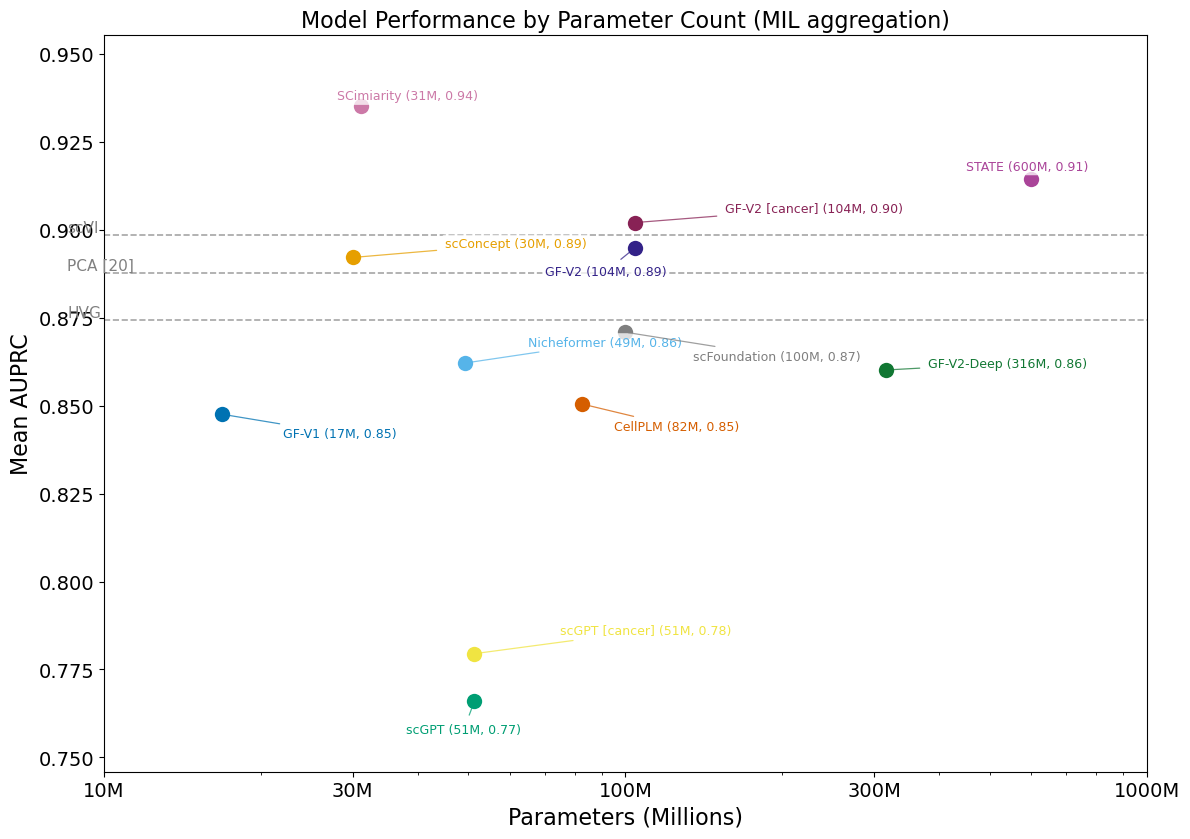

Saved plots/param_size_mil.png


In [33]:
nonzero = model_means[model_means['params'] > 0].sort_values('params')
zero = model_means[model_means['params'] == 0].sort_values('mean_auprc', ascending=False)

# Colorblind-friendly palette (Wong / Okabe-Ito inspired)
MODEL_COLORS = {
    'GF-V1': '#0072B2',
    'scConcept': '#E69F00',
    'SCimiarity': '#CC79A7',
    'Nicheformer': '#56B4E9',
    'scGPT': '#009E73',
    'scGPT [cancer]': '#F0E442',
    'CellPLM': '#D55E00',
    'scFoundation': '#7F7F7F',
    'GF-V2': '#332288',
    'GF-V2 [cancer]': '#882255',
    'GF-V2-Deep': '#117733',
    'STATE': '#AA4499',
}

# Label anchors in data coordinates — separates models that share the same x (e.g. GF-V2 pair)
LABEL_ANCHORS = {
    'GF-V1': (2.2e7, 0.842),
    'scConcept': (4.5e7, 0.896),
    'SCimiarity': (2.8e7, 0.938),
    'Nicheformer': (6.5e7, 0.868),
    'scGPT': (3.8e7, 0.758),
    'scGPT [cancer]': (7.5e7, 0.786),
    'CellPLM': (9.5e7, 0.844),
    'scFoundation': (1.35e8, 0.864),
    'GF-V2': (7.0e7, 0.888),
    'GF-V2 [cancer]': (1.55e8, 0.906),
    'GF-V2-Deep': (3.8e8, 0.862),
    'STATE': (4.5e8, 0.918),
}

fig, ax = plt.subplots(figsize=(12, 8.5))

for _, row in nonzero.iterrows():
    model = row['model_display']
    color = MODEL_COLORS[model]
    ax.scatter(
        row['params'],
        row['mean_auprc'],
        s=150,
        color=color,
        edgecolor='white',
        linewidth=1.2,
        zorder=3,
    )

for _, row in nonzero.iterrows():
    model = row['model_display']
    color = MODEL_COLORS[model]
    label = f"{model} ({row['params'] / 1e6:.0f}M, {row['mean_auprc']:.2f})"
    ax.annotate(
        label,
        xy=(row['params'], row['mean_auprc']),
        xytext=LABEL_ANCHORS[model],
        textcoords='data',
        fontsize=9,
        color=color,
        ha='left',
        va='center',
        arrowprops=dict(
            arrowstyle='-',
            color=color,
            lw=0.9,
            alpha=0.75,
            shrinkA=4,
            shrinkB=2,
        ),
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.75),
    )

for _, row in zero.iterrows():
    ax.axhline(y=row['mean_auprc'], linestyle='--', linewidth=1.2, color='gray', alpha=0.7)
    ax.text(
        8.5e6,
        row['mean_auprc'],
        row['model_display'],
        fontsize=11,
        va='bottom',
        ha='left',
        color='gray',
    )

ax.set_xscale('log')
xticks = [1e7, 3e7, 1e8, 3e8, 1e9]
ax.set_xticks(xticks)
ax.set_xticklabels([f'{int(x / 1e6)}M' for x in xticks], fontsize=14)
ax.set_xlabel('Parameters (Millions)', fontsize=16)
ax.set_ylabel('Mean AUPRC', fontsize=16)
ax.set_title(f'Model Performance by Parameter Count ({STRATEGY} aggregation)', fontsize=16)
ax.set_ylim(model_means['mean_auprc'].min() - 0.02, model_means['mean_auprc'].max() + 0.02)
ax.tick_params(labelsize=14)
ax.grid(False)

fig.tight_layout()
out_path = PLOTS_DIR / f'param_size_{STRATEGY.lower()}.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {out_path}')